# Spike Data Preparation

Download raw DMS functional selection data for SARS-CoV-2 spike variants
(Delta, BA.1, BA.2), apply improved count-aggregation data preparation,
and save training functional scores.

**Outline**
1. Download raw data from the public repository (cached for subsequent runs)
2. Load and concatenate raw functional selection CSVs
3. Select replicates and map to condition names
4. Remove deletions and invalid variants
5. Aggregate barcode counts per (condition, replicate, aa_substitutions)
6. Apply count-based filtering (pre_count, post_count thresholds)
7. Apply mutation-number filtering (max_subs)
8. Truncate nonsense variants (premature-stop logic)
9. Compute functional scores as log-ratios of aggregated counts
10. Subtract wildtype score, clip, and save
11. Replicate correlation analysis

In [1]:
import warnings

warnings.filterwarnings("ignore")

import os
import sys

sys.path.insert(0, "notebooks")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from _common import download_data, load_config, load_raw_data, truncate_nonsense

%matplotlib inline

In [2]:
config_path = "config/config.yaml"
output_dir = None

In [3]:
# Parameters
config_path = "config/config.yaml"
output_dir = "results-prod-235-times-seen-threshold"


In [4]:
config = load_config(config_path)
spike = config["spike"]
seed = config["seed"]

reference = spike["reference"]
experiment_conditions = spike["experiment_conditions"]
replicate_1_experiments = spike["replicate_1_experiments"]
replicate_2_experiments = spike["replicate_2_experiments"]
pre_count_threshold = spike["pre_count_threshold"]
post_count_threshold = spike["post_count_threshold"]
max_subs = spike["max_subs"]
func_score_clip = spike["func_score_clip"]
pseudocount = spike["pseudocount"]
do_truncate_nonsense = spike["do_truncate_nonsense"]
subsample_frac = spike.get("subsample_frac", None)
condition_colors = spike["condition_colors"]
condition_titles = spike["condition_titles"]

if output_dir is None:
    output_dir = spike.get("output_dir", "results")
os.makedirs(output_dir, exist_ok=True)

np.random.seed(seed)
print(f"Reference: {reference}")
print(f"Conditions: {experiment_conditions}")
print(f"Replicate 1: {replicate_1_experiments}")
print(f"Replicate 2: {replicate_2_experiments}")

Reference: Omicron_BA1
Conditions: ['Delta', 'Omicron_BA1', 'Omicron_BA2']
Replicate 1: ['Delta-2', 'Omicron_BA1-2', 'Omicron_BA2-1']
Replicate 2: ['Delta-4', 'Omicron_BA1-3', 'Omicron_BA2-2']


## Download and load raw data

Download raw functional selection CSVs from the public GitHub repository.
Files are cached locally in `results/raw_data/` for subsequent runs.

In [5]:
print("Downloading raw data (skips if cached)...")
raw_df = load_raw_data(spike, cache_dir=os.path.join(output_dir, "raw_data"))
print(f"Loaded {len(raw_df):,} total variant rows across all experiments")
print(f"Experiments: {sorted(raw_df['condition'].unique())}")

Loaded 1,135,096 total variant rows across all experiments
Experiments: ['Delta-1', 'Delta-2', 'Delta-3', 'Delta-4', 'Omicron_BA1-1', 'Omicron_BA1-2', 'Omicron_BA1-3', 'Omicron_BA2-1', 'Omicron_BA2-2']


## Select replicates

Map experiment names (e.g. Delta-2) to condition + replicate number.

In [6]:
rep1_df = (
    raw_df.query("condition in @replicate_1_experiments")
    .assign(
        condition=lambda df: df["condition"].replace(
            dict(zip(replicate_1_experiments, experiment_conditions))
        ),
        replicate="1",
    )
)
rep2_df = (
    raw_df.query("condition in @replicate_2_experiments")
    .assign(
        condition=lambda df: df["condition"].replace(
            dict(zip(replicate_2_experiments, experiment_conditions))
        ),
        replicate="2",
    )
)
df = pd.concat([rep1_df, rep2_df], ignore_index=True)
print(f"Selected {len(df):,} variant rows across replicates")
print(f"Conditions: {sorted(df['condition'].unique())}")
print(f"Variants per condition/replicate:")
print(df.groupby(["condition", "replicate"]).size().to_string())

Selected 780,734 variant rows across replicates
Conditions: ['Delta', 'Omicron_BA1', 'Omicron_BA2']
Variants per condition/replicate:
condition    replicate
Delta        1             83172
             2             79388
Omicron_BA1  1            140643
             2            125127
Omicron_BA2  1            181984
             2            170420


## Remove deletions and invalid variants

Drop variants with deletion characters (`-`) in substitutions, and
variants with stop-codon wildtype or non-numeric site numbering.

In [7]:
n_before = len(df)

# Remove deletions
has_deletion = df["aa_substitutions"].str.contains("-", regex=False)
df = df.loc[~has_deletion].copy()
print(f"Removed {has_deletion.sum():,} variants with deletions")

# Remove stop-codon wildtypes (substitutions starting with *)
has_stop_wt = df["aa_substitutions"].str.contains(r"(^|\s)\*", regex=True)
df = df.loc[~has_stop_wt].copy()
print(f"Removed {has_stop_wt.sum():,} variants with stop-codon wildtype")

# Remove non-numeric site numbering (indels)
has_non_numeric = df["aa_substitutions"].str.contains(
    r"[^0-9][A-Za-z*\-](\s|$)", regex=True
)
df = df.loc[~has_non_numeric].copy()
print(f"Removed {has_non_numeric.sum():,} variants with non-numeric sites")

print(f"\nTotal removed: {n_before - len(df):,} ({len(df):,} remaining)")

Removed 16,035 variants with deletions
Removed 497 variants with stop-codon wildtype


Removed 9,806 variants with non-numeric sites

Total removed: 26,338 (754,396 remaining)


## Aggregate barcode counts

Sum pre-selection and post-selection counts for identical variants
(same condition, replicate, and amino acid substitutions). This is the
improved count-aggregation approach from the jaxmodels empirical fits
notebook — statistically more principled than averaging pre-computed
functional scores.

In [8]:
df["n_subs"] = df["aa_substitutions"].apply(
    lambda x: len(x.split()) if x.strip() else 0
)

n_before_agg = len(df)
df = (
    df.groupby(["condition", "replicate", "aa_substitutions"], dropna=False)
    .agg({"n_subs": "first", "pre_count": "sum", "post_count": "sum"})
    .reset_index()
)
print(f"Aggregated {n_before_agg:,} barcode rows \u2192 {len(df):,} unique variants")

Aggregated 754,396 barcode rows → 326,545 unique variants


### Pre vs post count distribution

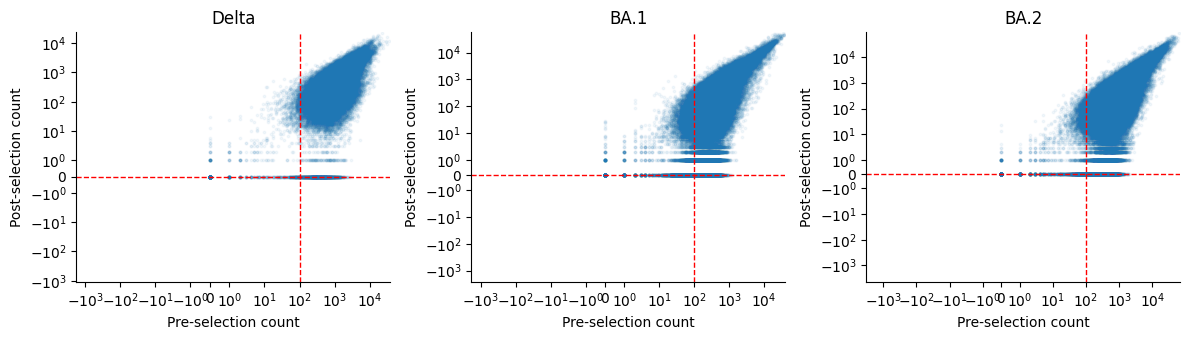

In [9]:
mutant_mask = df["aa_substitutions"] != ""
fig, axes = plt.subplots(1, len(experiment_conditions), figsize=(4 * len(experiment_conditions), 3.5))
for ax, cond in zip(axes, experiment_conditions):
    cond_mask = (df["condition"] == cond) & mutant_mask
    ax.scatter(
        df.loc[cond_mask, "pre_count"],
        df.loc[cond_mask, "post_count"],
        s=3, alpha=0.05, rasterized=True,
    )
    ax.axvline(pre_count_threshold, color="red", linestyle="--", linewidth=1)
    ax.axhline(post_count_threshold, color="red", linestyle="--", linewidth=1)
    ax.set_xscale("symlog", linthresh=1, linscale=0.5)
    ax.set_yscale("symlog", linthresh=1, linscale=0.5)
    ax.set_xlabel("Pre-selection count")
    ax.set_ylabel("Post-selection count")
    ax.set_title(condition_titles.get(cond, cond))
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Count-based filtering

Filter variants by minimum pre-selection and post-selection counts.

In [10]:
n_before = len(df)
df = df.query(
    "pre_count >= @pre_count_threshold and post_count >= @post_count_threshold"
).copy()
print(
    f"Count filter (pre >= {pre_count_threshold}, post >= {post_count_threshold}): "
    f"{n_before - len(df):,} removed, {len(df):,} remaining"
)

Count filter (pre >= 100, post >= 0): 21,092 removed, 305,453 remaining


## Mutation-number filtering

In [11]:
n_before = len(df)
df = df.query("n_subs <= @max_subs").copy()
print(
    f"Mutation-number filter (n_subs <= {max_subs}): "
    f"{n_before - len(df):,} removed, {len(df):,} remaining"
)

Mutation-number filter (n_subs <= 10): 101 removed, 305,352 remaining


### Substitution count distribution

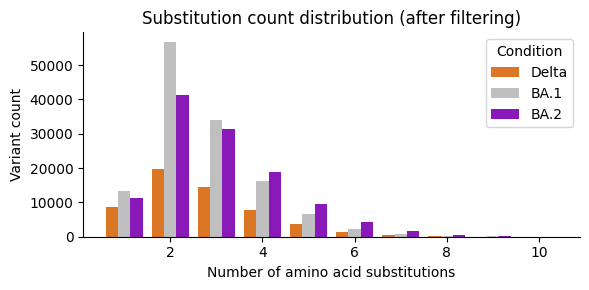

In [12]:
fig, ax = plt.subplots(figsize=(6, 3))
sns.countplot(
    data=df[df["aa_substitutions"] != ""],
    x="n_subs", hue="condition",
    palette=condition_colors,
    native_scale=True, ax=ax,
)
ax.set_xlabel("Number of amino acid substitutions")
ax.set_ylabel("Variant count")
ax.set_title("Substitution count distribution (after filtering)")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Condition", labels=[condition_titles.get(c, c) for c in experiment_conditions])
plt.tight_layout()
plt.show()

## Premature-stop truncation (stops + upstream missense retained)

For variants containing stop codons, truncate mutations to include only
those up to and including the first stop. Then re-aggregate counts for
newly identical variants. Truncated variants that retain upstream missense
mutations (e.g. `A100G D200*`) are kept — the missense effect on selection
is real since it occurred before the stop.

Nonsense truncation: 305352 → 303007 variants (2345 removed/merged)


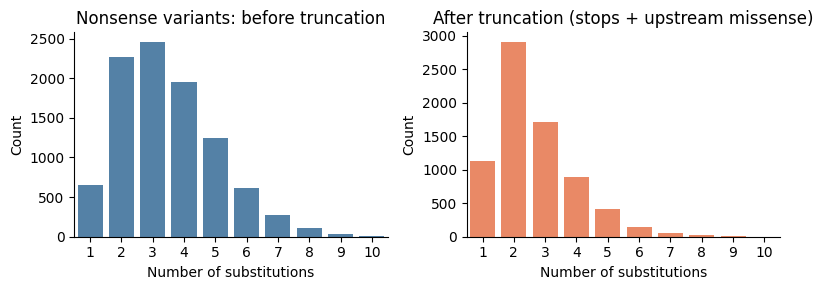

In [13]:
nonsense_mask = df["aa_substitutions"].str.contains("*", regex=False)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
sns.countplot(
    data=df.loc[nonsense_mask], x="n_subs",
    ax=axes[0], color="steelblue",
)
axes[0].set_title("Nonsense variants: before truncation")
axes[0].set_xlabel("Number of substitutions")
axes[0].set_ylabel("Count")
axes[0].spines[["top", "right"]].set_visible(False)

if do_truncate_nonsense:
    n_before = len(df)
    df = df.apply(truncate_nonsense, axis=1)

    # Re-aggregate identical variants after truncation
    df = (
        df.groupby(["condition", "replicate", "aa_substitutions"], dropna=False)
        .agg({"n_subs": "first", "pre_count": "sum", "post_count": "sum"})
        .reset_index()
    )

    print(
        f"Nonsense truncation: {n_before} → {len(df)} variants "
        f"({n_before - len(df)} removed/merged)"
    )

    nonsense_mask_after = df["aa_substitutions"].str.contains("*", regex=False)
    sns.countplot(
        data=df.loc[nonsense_mask_after], x="n_subs",
        ax=axes[1], color="coral",
    )
    axes[1].set_title("After truncation (stops + upstream missense)")
else:
    axes[1].set_title("Truncation disabled")

axes[1].set_xlabel("Number of substitutions")
axes[1].set_ylabel("Count")
axes[1].spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Compute functional scores

Functional scores are log2-ratios of aggregated counts:
$$f = \log_2(\text{post\_count} + \epsilon) - \log_2(\text{pre\_count} + \epsilon)$$
where $\epsilon$ is the pseudocount. Using log2 aligns with `dms-vep-pipeline-3`.

In [14]:
df["func_score"] = (
    np.log2(df["post_count"] + pseudocount) - np.log2(df["pre_count"] + pseudocount)
)
print(f"Raw func_score range: [{df['func_score'].min():.3f}, {df['func_score'].max():.3f}]")

Raw func_score range: [-12.580, 4.357]


## Wildtype subtraction

Subtract the wildtype functional score within each (condition, replicate) group
so that wildtype variants have score 0.

In [15]:
wt_scores = (
    df.query("aa_substitutions == ''")
    .rename(columns={"func_score": "wt_func_score"})
    [["condition", "replicate", "wt_func_score"]]
)
assert len(wt_scores) == len(df.groupby(["condition", "replicate"])), (
    f"Expected one WT per group, got {len(wt_scores)}"
)

df = df.merge(wt_scores, on=["condition", "replicate"])
df["func_score"] = df["func_score"] - df["wt_func_score"]
df = df.drop(columns=["wt_func_score"])
print("WT-subtracted func_score range: "
      f"[{df['func_score'].min():.3f}, {df['func_score'].max():.3f}]")

WT-subtracted func_score range: [-12.293, 4.047]


## Clip functional scores

In [16]:
clip_lo, clip_hi = func_score_clip
n_below = (df["func_score"] < clip_lo).sum()
n_above = (df["func_score"] > clip_hi).sum()
print(f"Clipping to [{clip_lo}, {clip_hi}]: {n_below:,} below, {n_above:,} above")
df["func_score"] = df["func_score"].clip(clip_lo, clip_hi)

Clipping to [-3.5, 2.5]: 60,570 below, 74 above


## Subsample (test profile only)

In [17]:
if subsample_frac is not None:
    n_before = len(df)
    wt_rows = df[df["aa_substitutions"] == ""]
    non_wt_rows = df[df["aa_substitutions"] != ""]
    subsampled = pd.concat([
        g.sample(frac=subsample_frac, random_state=seed)
        for _, g in non_wt_rows.groupby(["condition", "replicate"])
    ])
    df = pd.concat([wt_rows, subsampled]).reset_index(drop=True)
    print(f"Subsampled: {n_before:,} \u2192 {len(df):,} variants (frac={subsample_frac}, WT kept)")
else:
    print("No subsampling (production profile)")

No subsampling (production profile)


## Save training data

In [18]:
output_cols = ["aa_substitutions", "condition", "replicate", "func_score", "n_subs", "pre_count", "post_count"]
df_out = df[output_cols].copy()

output_path = os.path.join(output_dir, "training_functional_scores.csv")
df_out.to_csv(output_path, index=False)
print(f"Saved {output_path}")
print(f"  {len(df_out):,} variants")
print(f"  Conditions: {sorted(df_out['condition'].unique())}")
print(f"  Replicates: {sorted(df_out['replicate'].unique())}")
print(f"\nVariants per condition/replicate:")
print(df_out.groupby(["condition", "replicate"]).size().to_string())

Saved results-prod-235-times-seen-threshold/training_functional_scores.csv
  303,007 variants
  Conditions: ['Delta', 'Omicron_BA1', 'Omicron_BA2']
  Replicates: ['1', '2']

Variants per condition/replicate:
condition    replicate
Delta        1            28046
             2            27734
Omicron_BA1  1            68699
             2            60538
Omicron_BA2  1            60550
             2            57440


## Functional score distributions

Histograms of functional scores per condition, overlaying both replicates.

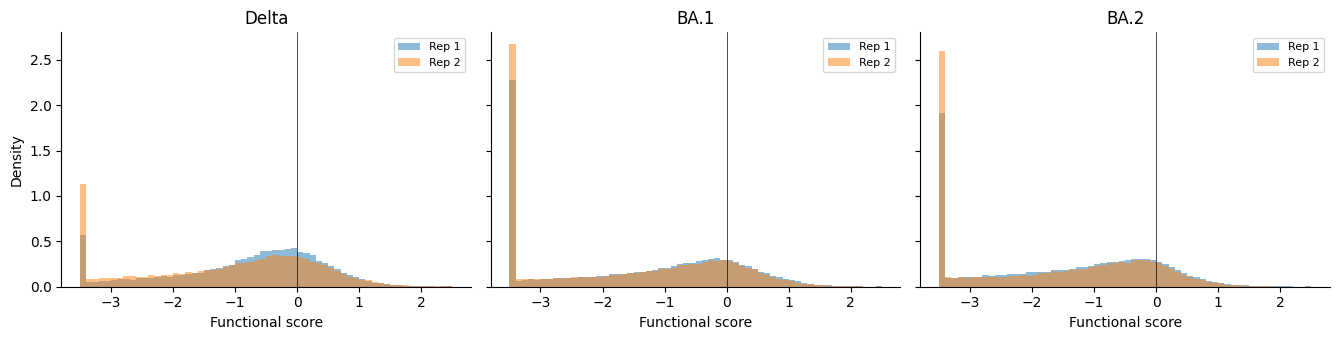

In [19]:
mutants = df.query("aa_substitutions != ''")

fig, axes = plt.subplots(
    1, len(experiment_conditions),
    figsize=(4.5 * len(experiment_conditions), 3.5),
    sharey=True,
)
for ax, cond in zip(axes, experiment_conditions):
    for rep in sorted(mutants["replicate"].unique()):
        subset = mutants.query("condition == @cond and replicate == @rep")
        ax.hist(
            subset["func_score"], bins=60, alpha=0.5,
            label=f"Rep {rep}", density=True,
        )
    ax.axvline(0, color="black", linestyle="-", linewidth=0.5)
    ax.set_xlabel("Functional score")
    if ax == axes[0]:
        ax.set_ylabel("Density")
    ax.set_title(condition_titles.get(cond, cond))
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Replicate correlation analysis

For each condition, merge replicate 1 and replicate 2 functional scores
on `aa_substitutions`, then compute the Pearson correlation.
High replicate correlations (r > 0.8) validate the data preparation.

In [20]:
replicates = sorted(df["replicate"].unique())
corr_data = {}
for cond in experiment_conditions:
    rep1 = (
        df.query("condition == @cond and replicate == @replicates[0] and aa_substitutions != ''")
        [["aa_substitutions", "func_score"]]
        .rename(columns={"func_score": "rep1"})
    )
    rep2 = (
        df.query("condition == @cond and replicate == @replicates[1] and aa_substitutions != ''")
        [["aa_substitutions", "func_score"]]
        .rename(columns={"func_score": "rep2"})
    )
    merged = rep1.merge(rep2, on="aa_substitutions", how="inner")
    if len(merged) >= 2:
        r, p = stats.pearsonr(merged["rep1"], merged["rep2"])
    else:
        r, p = float("nan"), float("nan")
    corr_data[cond] = {"merged": merged, "r": r, "p": p, "n": len(merged)}
    print(f"{condition_titles.get(cond, cond):>6s}: r = {r:.4f}  (n = {len(merged):,} shared variants)")

 Delta: r = 0.5982  (n = 3,066 shared variants)
  BA.1: r = 0.8912  (n = 5,774 shared variants)
  BA.2: r = 0.8547  (n = 4,502 shared variants)


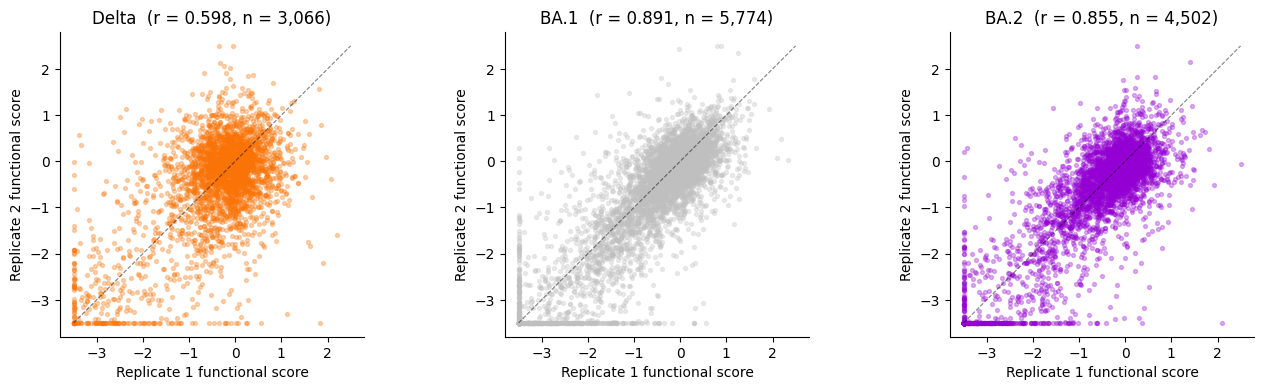

In [21]:
fig, axes = plt.subplots(
    1, len(experiment_conditions),
    figsize=(4.5 * len(experiment_conditions), 4),
)
for ax, cond in zip(axes, experiment_conditions):
    merged = corr_data[cond]["merged"]
    r = corr_data[cond]["r"]
    color = condition_colors[cond]

    ax.scatter(
        merged["rep1"], merged["rep2"],
        s=8, alpha=0.3, color=color, rasterized=True,
    )
    # Identity line
    if len(merged) > 0:
        lims = [
            min(merged["rep1"].min(), merged["rep2"].min()),
            max(merged["rep1"].max(), merged["rep2"].max()),
        ]
        ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.5)
    ax.set_xlabel("Replicate 1 functional score")
    ax.set_ylabel("Replicate 2 functional score")
    title = condition_titles.get(cond, cond)
    ax.set_title(f"{title}  (r = {r:.3f}, n = {len(merged):,})")
    ax.set_aspect("equal", adjustable="box")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()